In [1]:
import pandas as pd
save_path = r"C:\Users\seohg\OneDrive\바탕 화면\2026\seoul datalob contest"

# pivot_df 불러오기
result_df = pd.read_csv(f"{save_path}\\result_final.csv", index_col="위치ID")

In [2]:
result_df.head(1)

,공실횟수,생존횟수,교체횟수,TRDAR_CD,TRDAR_CD_N,TRDAR_SE_1,상권평균공실,상권평균생존,상권평균교체,상권위치수,...,위도,경도,시군구명,행정동명,도로명주소,공실_zscore,생존_zscore,교체_zscore,위험점수,상권내_위험순위
위치ID,,,,,,,,,,,,,,,,,,,,,
1111010100100390006031458_1_nan,3,36,0,3110011,청운초등학교,골목상권,14.419355,23.935484,0.548387,31.0,...,37.5875,126.969283,종로구,청운효자동,서울특별시 종로구 자하문로 131,-0.802566,0.875723,-0.34993,-2.028219,24.0


In [3]:
result_df.columns

Index(['공실횟수', '생존횟수', '교체횟수', 'TRDAR_CD', 'TRDAR_CD_N', 'TRDAR_SE_1',
       '상권평균공실', '상권평균생존', '상권평균교체', '상권위치수', '공실_상권대비', '생존_상권대비', '교체_상권대비',
       '위도', '경도', '시군구명', '행정동명', '도로명주소', '공실_zscore', '생존_zscore',
       '교체_zscore', '위험점수', '상권내_위험순위'],
      dtype='object')

In [4]:
import numpy as np

# 위험점수 분포 확인
print("=== 위험점수 분포 ===")
print(result_df["위험점수"].describe())

percentiles = [75, 80, 85, 90, 95, 99]
for p in percentiles:
    val = np.percentile(result_df["위험점수"].dropna(), p)
    count = (result_df["위험점수"] >= val).sum()
    print(f"{p}th percentile: {val:.2f} → {count}개 위치 ({count/len(result_df)*100:.1f}%)")

=== 위험점수 분포 ===
count    3.299370e+05
mean    -1.744392e-18
std      1.917431e+00
min     -4.459146e+00
25%     -1.637554e+00
50%     -7.366675e-02
75%      1.631327e+00
max      1.202072e+01
Name: 위험점수, dtype: float64
75th percentile: 1.63 → 82485개 위치 (25.0%)
80th percentile: 1.98 → 65988개 위치 (20.0%)
85th percentile: 2.30 → 49503개 위치 (15.0%)
90th percentile: 2.62 → 32994개 위치 (10.0%)
95th percentile: 3.01 → 16503개 위치 (5.0%)
99th percentile: 3.65 → 3300개 위치 (1.0%)


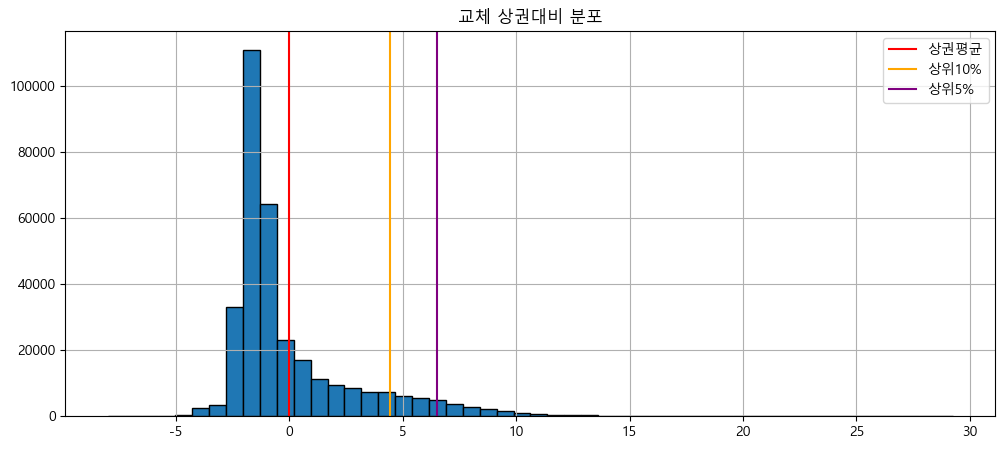

이상값 기준: 4.46
위험 위치 수: 33007개 (10.0%)


In [5]:
import matplotlib
import matplotlib.pyplot as plt

matplotlib.rc('font', family='Malgun Gothic')
matplotlib.rc('axes', unicode_minus=False)

# 분포 확인
result_df["교체_상권대비"].hist(bins=50, figsize=(12,5), edgecolor='black')
plt.axvline(0, color='red', label='상권평균')
plt.axvline(result_df["교체_상권대비"].quantile(0.9), color='orange', label='상위10%')
plt.axvline(result_df["교체_상권대비"].quantile(0.95), color='purple', label='상위5%')
plt.legend()
plt.title("교체 상권대비 분포")
plt.show()

# 상위 10% 기준 이상값
threshold = result_df["교체_상권대비"].quantile(0.9)
danger = result_df[result_df["교체_상권대비"] >= threshold]
print(f"이상값 기준: {threshold:.2f}")
print(f"위험 위치 수: {len(danger)}개 ({len(danger)/len(result_df)*100:.1f}%)")

In [6]:
danger = result_df[result_df["교체_상권대비"] >= threshold].copy()

danger.info()

<class 'pandas.core.frame.DataFrame'>
Index: 33007 entries, 1111010100100490002000002_nan_nan to 1174011000106790003000001_nan_nan
Data columns (total 23 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   공실횟수        33007 non-null  int64  
 1   생존횟수        33007 non-null  int64  
 2   교체횟수        33007 non-null  int64  
 3   TRDAR_CD    33007 non-null  int64  
 4   TRDAR_CD_N  33007 non-null  object 
 5   TRDAR_SE_1  33007 non-null  object 
 6   상권평균공실      33007 non-null  float64
 7   상권평균생존      33007 non-null  float64
 8   상권평균교체      33007 non-null  float64
 9   상권위치수       33007 non-null  float64
 10  공실_상권대비     33007 non-null  float64
 11  생존_상권대비     33007 non-null  float64
 12  교체_상권대비     33007 non-null  float64
 13  위도          33007 non-null  float64
 14  경도          33007 non-null  float64
 15  시군구명        33007 non-null  object 
 16  행정동명        33007 non-null  object 
 17  도로명주소       33007 non-null  object 
 18  공실_zscore  

In [8]:
danger_list= danger['TRDAR_CD_N'].value_counts()
result_list=result_df['TRDAR_CD_N'].value_counts()

# 상권별 위험 위치 수 / 전체 위치 수 / 비율
danger_ratio = pd.DataFrame({
    "위험위치수": danger_list,
    "전체위치수": result_list
}).fillna(0)

danger_ratio["위험비율(%)"] = (danger_ratio["위험위치수"] / danger_ratio["전체위치수"] * 100).round(2)
danger_ratio = danger_ratio.sort_values("위험비율(%)", ascending=False)

print(danger_ratio.head(30).to_string())

                                  위험위치수  전체위치수  위험비율(%)
TRDAR_CD_N                                             
등나무근린공원                            18.0     53    33.96
삼익패션타운(남대문시장)                      13.0     39    33.33
증산종합시장                              4.0     13    30.77
잠실나루역                               4.0     13    30.77
평화시장(통일상가, 동화상가)                   33.0    116    28.45
동대문종합시장(동대문종합시장 신관, 동대문종합시장D동상가)    9.0     32    28.12
구반포역                                8.0     29    27.59
연산군묘                                3.0     11    27.27
신월7동 골목시장(약수시장, 우성상가)               6.0     22    27.27
숭례문수입상가(남대문시장)                      3.0     11    27.27
장지역(가든파이브)                         27.0    100    27.00
누원고등학교                              9.0     36    25.00
인왕시장(홍제골목형상점가)                     15.0     61    24.59
이촌동점보아파트                            8.0     33    24.24
경동시장                                5.0     21    23.81
영서중학교                               5.0     21  

In [9]:
from scipy import stats

# 상권별로 교체횟수의 분산(표준편차) 확인
variance_by_sangkwon = result_df.groupby("TRDAR_CD")["교체횟수"].agg(
    평균=("mean"),
    표준편차=("std"),
    변동계수=lambda x: x.std()/x.mean() * 100  # CV = 표준편차/평균 * 100
).reset_index()

print(variance_by_sangkwon.describe())
print("\n변동계수 상위 20개 (개인차가 큰 상권)")
print(variance_by_sangkwon.sort_values("변동계수", ascending=False).head(20).to_string())

           TRDAR_CD           평균         표준편차         변동계수
count  1.590000e+03  1590.000000  1590.000000  1589.000000
mean   3.114750e+06     1.683057     2.778578   184.559893
std    1.014375e+04     0.947778     0.794837    44.965229
min    3.001491e+06     0.000000     0.000000    54.377633
25%    3.110394e+06     1.147483     2.293514   157.749418
50%    3.110794e+06     1.486841     2.717795   180.045687
75%    3.120105e+06     1.946899     3.175483   204.848481
max    3.130327e+06     8.000000     6.415260   438.973084

변동계수 상위 20개 (개인차가 큰 상권)
     TRDAR_CD        평균      표준편차        변동계수
841   3110841  0.137931  0.605480  438.973084
388   3110385  0.178571  0.772374  432.529168
893   3110894  0.058824  0.242536  412.310563
535   3110533  0.058824  0.238833  406.015375
497   3110494  0.062500  0.250000  400.000000
284   3110280  0.108696  0.433501  398.820483
51    3110046  0.484848  1.872852  386.275788
494   3110491  0.553191  2.103915  380.323038
22    3110017  0.535714  1.990

C:\Users\seohg\AppData\Local\Temp\ipykernel_113284\1518778094.py:7: RuntimeWarning: invalid value encountered in scalar divide
  변동계수=lambda x: x.std()/x.mean() * 100  # CV = 표준편차/평균 * 100


In [10]:
danger_ratio.sort_values('전체위치수',ascending=False)

,위험위치수,전체위치수,위험비율(%)
TRDAR_CD_N,,,
명동 남대문 북창동 다동 무교동 관광특구,404.0,3347,12.07
홍대입구역(홍대),195.0,2884,6.76
강남역,416.0,2683,15.51
종로·청계 관광특구,234.0,2580,9.07
역삼역,344.0,2426,14.18
...,...,...,...
영진시장,2.0,10,20.00
개포지하차도 북측,0.0,10,0.00
대림썬프라자,2.0,10,20.00


In [11]:
danger_ratio.sort_values('위험위치수',ascending=False)

,위험위치수,전체위치수,위험비율(%)
TRDAR_CD_N,,,
강남역,416.0,2683,15.51
명동 남대문 북창동 다동 무교동 관광특구,404.0,3347,12.07
역삼역,344.0,2426,14.18
가산디지털단지,331.0,1772,18.68
교대역(법원.검찰청),301.0,2188,13.76
...,...,...,...
사당종합체육관,0.0,47,0.00
증산3교남측,0.0,16,0.00
신대방삼거리역 4번(대림초등학교),0.0,58,0.00


In [12]:
danger_ratio[danger_ratio["위험비율(%)"] >= 10].sort_values('위험위치수', ascending=False)

,위험위치수,전체위치수,위험비율(%)
TRDAR_CD_N,,,
강남역,416.0,2683,15.51
명동 남대문 북창동 다동 무교동 관광특구,404.0,3347,12.07
역삼역,344.0,2426,14.18
가산디지털단지,331.0,1772,18.68
교대역(법원.검찰청),301.0,2188,13.76
...,...,...,...
마전교지하쇼핑센터(구 한일상가),2.0,15,13.33
대림썬프라자,2.0,10,20.00
동대문상가A동,2.0,10,20.00


In [13]:
# 위험 기준값 (상위 10%)
threshold = result_df["교체_상권대비"].quantile(0.9)

# 위험 위치들의 교체횟수 분포
danger = result_df[result_df["교체_상권대비"] >= threshold]

print(f"위험 기준값 (교체_상권대비): {threshold:.2f}")
print(f"위험 위치 수: {len(danger)}개")
print("\n=== 위험 위치 교체횟수 분포 ===")
print(danger["교체횟수"].describe())
print("\n교체횟수 분포:")
print(danger["교체횟수"].value_counts().sort_index())

위험 기준값 (교체_상권대비): 4.46
위험 위치 수: 33007개

=== 위험 위치 교체횟수 분포 ===
count    33007.000000
mean         9.137456
std          2.705524
min          5.000000
25%          7.000000
50%          8.000000
75%         10.000000
max         31.000000
Name: 교체횟수, dtype: float64

교체횟수 분포:
교체횟수
5       14
6     3352
7     6435
8     6755
9     4860
10    4152
11    2662
12    1631
13    1000
14     621
15     416
16     337
17     228
18     162
19     116
20      79
21      58
22      35
23      28
24      25
25      13
26      12
27       6
28       6
29       3
31       1
Name: count, dtype: int64


In [14]:
danger_ratio.to_csv(f"{save_path}\\danger_ratio.csv")

In [18]:
import folium
from folium.plugins import HeatMap

danger = result_df[result_df["교체_상권대비"] >= threshold][["위도","경도","교체_상권대비"]].dropna()

m = folium.Map(location=[37.545, 126.986], zoom_start=11)

HeatMap(
    danger[["위도","경도","교체_상권대비"]].values.tolist(),
    radius=8, blur=5, max_zoom=14, min_opacity=0.3
).add_to(m)

# 범례 추가
legend_html = '''
<div style="position: fixed; bottom: 30px; right: 30px; z-index: 1000;
     background: white; padding: 15px; border-radius: 8px;
     border: 1px solid #ccc; font-size: 13px;">
  <b>교체율 위험도</b><br><br>
  <div style="display:flex; align-items:center; gap:8px; margin-bottom:5px;">
    <div style="width:20px; height:15px; background:#d73027;"></div> 매우 높음
  </div>
  <div style="display:flex; align-items:center; gap:8px; margin-bottom:5px;">
    <div style="width:20px; height:15px; background:#f46d43;"></div> 높음
  </div>
  <div style="display:flex; align-items:center; gap:8px; margin-bottom:5px;">
    <div style="width:20px; height:15px; background:#fee090;"></div> 보통
  </div>
  <div style="display:flex; align-items:center; gap:8px; margin-bottom:5px;">
    <div style="width:20px; height:15px; background:#74add1;"></div> 낮음
  </div>
  <div style="display:flex; align-items:center; gap:8px;">
    <div style="width:20px; height:15px; background:#4575b4;"></div> 매우 낮음
  </div>
</div>
'''
m.get_root().html.add_child(folium.Element(legend_html))

m.save(r"C:\Users\seohg\OneDrive\바탕 화면\2026\seoul datalob contest\danger_heatmap.html")
print("저장 완료!")

저장 완료!


In [20]:
# 상권별 대표 좌표 추출
sangkwon_coords = result_df.groupby("TRDAR_CD_N")[["위도","경도"]].mean().reset_index()

# danger_ratio에 좌표 붙이기
danger_ratio_map = danger_ratio.merge(sangkwon_coords, on="TRDAR_CD_N", how="left")

heat_data = danger_ratio_map[["위도","경도","위험비율(%)"]].dropna().values.tolist()

m = folium.Map(location=[37.545, 126.986], zoom_start=11)
HeatMap(heat_data, radius=10, blur=8, max_zoom=14, min_opacity=0.3).add_to(m)

legend_html = '''
<div style="position: fixed; bottom: 30px; right: 30px; z-index: 1000;
     background: white; padding: 15px; border-radius: 8px;
     border: 1px solid #ccc; font-size: 13px;">
  <b>상권 내 위험 위치 비율</b><br>
  <span style="font-size:11px; color:#888;">(위험위치수 / 전체위치수 × 100)</span><br><br>
  <div style="display:flex; align-items:center; gap:8px; margin-bottom:5px;">
    <div style="width:20px; height:15px; background:#d73027;"></div> 높음 (10%+)
  </div>
  <div style="display:flex; align-items:center; gap:8px; margin-bottom:5px;">
    <div style="width:20px; height:15px; background:#f46d43;"></div> 중상 (8~10%)
  </div>
  <div style="display:flex; align-items:center; gap:8px; margin-bottom:5px;">
    <div style="width:20px; height:15px; background:#fee090;"></div> 보통 (5~8%)
  </div>
  <div style="display:flex; align-items:center; gap:8px; margin-bottom:5px;">
    <div style="width:20px; height:15px; background:#74add1;"></div> 낮음 (2~5%)
  </div>
  <div style="display:flex; align-items:center; gap:8px;">
    <div style="width:20px; height:15px; background:#4575b4;"></div> 매우 낮음 (~2%)
  </div>
</div>
'''
m.get_root().html.add_child(folium.Element(legend_html))
m.save(f"{save_path}\\danger_ratio_heatmap.html")
print("저장 완료!")

저장 완료!


In [ ]:
import glob, os, pandas as pd, gc

folder = r"C:\Users\seohg\OneDrive\바탕 화면\2026\seoul datalob contest\store_name_1525\data"
save_path = r"C:\Users\seohg\OneDrive\바탕 화면\2026\seoul datalob contest"

# 1. dfs 로드
dfs = {}
for file in glob.glob(f"{folder}\\*.csv"):
    name = os.path.basename(file).replace(".csv", "")[-6:]
    dfs[f"df_{name}"] = pd.read_csv(file, low_memory=False)

# 2. df_all 생성
df_all = pd.concat([df.assign(period=name) for name, df in dfs.items()], ignore_index=True)
del dfs; gc.collect()

# 건물관리번호 없는 행 제거
df_all = df_all[df_all["건물관리번호"].notna()]

# 위치ID 생성
df_all["위치ID"] = (
    df_all["건물관리번호"].astype(str) + "_" +
    df_all["층정보"].astype(str) + "_" +
    df_all["호정보"].astype(str)
)

# 3. location_meta 저장
location_meta = df_all.groupby("위치ID").agg(
    위도=("위도", "first"),
    경도=("경도", "first"),
    시군구명=("시군구명", "first"),
    행정동명=("행정동명", "first"),
    건물관리번호=("건물관리번호", "first"),
    도로명주소=("도로명주소", "first"),
    층정보=("층정보", "first")
).reset_index()
location_meta.to_csv(f"{save_path}\\location_meta.csv", index=False, encoding='utf-8-sig')
del location_meta; gc.collect()
print("✅ location_meta 저장 완료!")

# 4. pivot_df 저장
pivot_df = df_all.groupby(["위치ID", "period"])["상가업소번호"].first().unstack("period")
pivot_df.to_csv(f"{save_path}\\pivot_df.csv")
del pivot_df; gc.collect()
print("✅ pivot_df 저장 완료!")

# 5. shop_history_raw 저장
shop_history_raw = df_all[["위치ID", "상가업소번호", "period", 
                            "상권업종소분류명", "상권업종중분류명",
                            "상권업종대분류명", "시군구명", "행정동명"]].copy()
shop_history_raw.to_csv(f"{save_path}\\shop_history_raw.csv", index=False, encoding='utf-8-sig')
del df_all; gc.collect()
print("✅ shop_history_raw 저장 완료!")

In [ ]:
# 6. pivot_df로 위치별 지표 계산
pivot_df = pd.read_csv(f"{save_path}\\pivot_df.csv", index_col="위치ID")

vacancy_count = pivot_df.isna().sum(axis=1)
survival_count = (
    (pivot_df == pivot_df.shift(axis=1)) &
    pivot_df.notna() &
    pivot_df.shift(axis=1).notna()
).sum(axis=1)
replacement_count = (
    (pivot_df != pivot_df.shift(axis=1)) &
    pivot_df.notna() &
    pivot_df.shift(axis=1).notna()
).sum(axis=1)

location_stats = pd.DataFrame({
    "공실횟수": vacancy_count,
    "생존횟수": survival_count,
    "교체횟수": replacement_count
})
location_stats = location_stats[~location_stats.index.str.startswith("nan")]

In [ ]:
# 7. 상권 매핑 및 result_final 생성
import geopandas as gpd

sangkwon = gpd.read_file(
    r"C:\Users\seohg\OneDrive\바탕 화면\2026\seoul datalob contest\area\서울시 상권분석서비스(영역-상권).shp",
    encoding='utf-8'
)

location_meta = pd.read_csv(f"{save_path}\\location_meta.csv")
location_gdf = gpd.GeoDataFrame(
    location_meta,
    geometry=gpd.points_from_xy(location_meta["경도"], location_meta["위도"]),
    crs="EPSG:4326"
).to_crs("EPSG:5181")

joined = gpd.sjoin(
    location_gdf,
    sangkwon[["TRDAR_CD", "TRDAR_CD_N", "TRDAR_SE_1", "geometry"]],
    how="left", predicate="within"
)

# 상권별 평균 계산
in_area_indexed = joined[joined["TRDAR_CD"].notna()][["위치ID","TRDAR_CD","TRDAR_CD_N","TRDAR_SE_1"]].set_index("위치ID")
stats_with_sangkwon = location_stats.join(in_area_indexed, how="left")

sangkwon_avg = stats_with_sangkwon[stats_with_sangkwon["TRDAR_CD"].notna()].groupby("TRDAR_CD").agg(
    상권평균공실=("공실횟수", "mean"),
    상권평균생존=("생존횟수", "mean"),
    상권평균교체=("교체횟수", "mean"),
    상권위치수=("공실횟수", "count")
).reset_index()

result = stats_with_sangkwon.reset_index().merge(sangkwon_avg, on="TRDAR_CD", how="left")
result["공실_상권대비"] = result["공실횟수"] - result["상권평균공실"]
result["생존_상권대비"] = result["생존횟수"] - result["상권평균생존"]
result["교체_상권대비"] = result["교체횟수"] - result["상권평균교체"]

result_in = result[result["TRDAR_CD"].notna()].copy()
result_final = result_in.merge(
    location_meta[["위치ID","위도","경도","시군구명","행정동명","도로명주소","층정보"]],
    on="위치ID", how="left"
)
result_final.to_csv(f"{save_path}\\result_final.csv", index=False, encoding='utf-8-sig')
print("✅ result_final 저장 완료!")